# 05 - Statistical and Diagnostic Analysis

## Objective

This notebook validates the project research questions using statistical hypothesis testing on the cleaned 2025 Airline On-Time Performance dataset.

The analysis defines null and alternative hypotheses, selects appropriate statistical tests, checks key assumptions, computes p-values and effect sizes, and documents whether each research hypothesis is supported.

Extended diagnostic analytics add Cramér's V interpretation, Kruskal-Wallis testing, Dunn post-hoc comparisons, and Spearman correlation analysis to address practical as well as statistical significance.

Statistical evidence generated here supports the final report and the downstream predictive and prescriptive stages of the project.

#### Load project configuration

In [0]:
from __future__ import annotations

import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

# Load the project configuration

from config import project_config as cfg

print("Project configuration loaded successfully.")
print(f"Source table: {cfg.CLEAN_TABLE}")
print(f"Results table: {cfg.STATISTICAL_RESULTS_TABLE}")
print(f"Significance level: {cfg.STATISTICAL_SIGNIFICANCE_ALPHA}")


Project configuration loaded successfully.
Source table: workspace.default.flights_clean
Results table: workspace.default.statistical_analysis_results
Significance level: 0.05


#### Load and validate the cleaned dataset

The statistical analysis uses the managed `flights_clean` table produced by the data-cleaning notebook. Only completed operational flights are retained for hypothesis testing.

In [0]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F


def require_table(table_name: str) -> None:
    """Raise an error when a required Unity Catalog table is unavailable."""
    if not spark.catalog.tableExists(table_name):
        raise RuntimeError(
            f"Required table '{table_name}' was not found. "
            "Run the data-cleaning notebook before continuing."
        )


require_table(cfg.CLEAN_TABLE)

df_clean: DataFrame = spark.table(cfg.CLEAN_TABLE)

clean_row_count = df_clean.count()
missing_columns = sorted(
    set(cfg.FEATURE_INPUT_COLUMNS) - set(df_clean.columns)
)

if missing_columns:
    raise ValueError(
        "Statistical-analysis validation failed. "
        f"Missing required columns: {missing_columns}"
    )

print("Cleaned dataset loaded and validated successfully.")
print(f"Total records: {clean_row_count:,}")
print(f"Prediction target: {cfg.TARGET_COLUMN}")


Cleaned dataset loaded and validated successfully.
Total records: 7,001,618
Prediction target: ARR_DEL15


#### Create the analysis population

Cancelled and diverted flights are excluded because the target variable represents arrival delay for completed flights. Schedule-time diagnostic fields are derived for statistical testing.

In [ ]:
# Build the SEASON and TIME_OF_DAY expressions from the shared project
# configuration (cfg.SEASON_MONTH_GROUPS / cfg.TIME_OF_DAY_BUCKETS) so this
# notebook's diagnostic categories always match the model feature definitions.

season_expression = None
for season_name, season_months in cfg.SEASON_MONTH_GROUPS.items():
    month_condition = F.col(cfg.MONTH_COLUMN).isin(*season_months)
    if season_expression is None:
        season_expression = F.when(month_condition, season_name)
    else:
        season_expression = season_expression.when(month_condition, season_name)

time_of_day_expression = None
for bucket in cfg.TIME_OF_DAY_BUCKETS:
    hour_condition = F.col(cfg.DEP_HOUR_COLUMN).between(
        bucket["start_hour"], bucket["end_hour"]
    )
    if time_of_day_expression is None:
        time_of_day_expression = F.when(hour_condition, bucket["label"])
    else:
        time_of_day_expression = time_of_day_expression.when(
            hour_condition, bucket["label"]
        )

df_analysis = (
    df_clean
    .filter(
        (F.col(cfg.CANCELLED_COLUMN) == cfg.MODEL_ELIGIBLE_STATUS_VALUE)
        & (F.col(cfg.DIVERTED_COLUMN) == cfg.MODEL_ELIGIBLE_STATUS_VALUE)
    )
    .withColumn(
        cfg.DEP_HOUR_COLUMN,
        F.floor(F.col(cfg.SCHEDULED_DEPARTURE_COLUMN) / 100).cast("int"),
    )
    .withColumn(
        cfg.IS_WEEKEND_COLUMN,
        F.when(
            F.col(cfg.DAY_OF_WEEK_COLUMN).isin(*cfg.WEEKEND_DAYS),
            F.lit(1),
        ).otherwise(F.lit(0)),
    )
    .withColumn(cfg.SEASON_COLUMN, season_expression)
    .withColumn(cfg.TIME_OF_DAY_COLUMN, time_of_day_expression)
)

analysis_row_count = df_analysis.count()

analysis_summary = spark.createDataFrame(
    [
        (
            clean_row_count,
            analysis_row_count,
            clean_row_count - analysis_row_count,
        )
    ],
    schema="CLEAN_ROWS long, ANALYSIS_ROWS long, EXCLUDED_ROWS long",
)

display(analysis_summary)

#### Define research questions and hypotheses

The research design follows the project proposal and final report.

| ID | Research Question |
|---|---|
| RQ1 | Can flight delays be accurately predicted before departure using operational flight information? |
| RQ2 | Which operational factors contribute the most to flight delays? |
| RQ3 | Do certain airlines and airports consistently experience higher delay rates than others? |
| RQ4 | Can prescriptive analytics improve operational decision-making by prioritizing high-risk flights under limited resources? |
| RQ5 | Can Explainable Artificial Intelligence (SHAP) improve the interpretability of flight delay predictions for airline operations? |

| Hypothesis | Null Hypothesis (H0) | Alternative Hypothesis (H1) |
|---|---|---|
| H1 | Operational flight variables do not significantly predict whether a flight will be delayed. | Operational flight variables significantly predict whether a flight will be delayed. |
| H2 | There is no statistically significant relationship between operational factors and arrival delays. | At least one operational factor has a statistically significant relationship with arrival delays. |
| H3 | There is no statistically significant difference in delay rates among airlines and airports. | There is a statistically significant difference in delay rates among airlines and airports. |
| H4 | Optimization-based prioritization does not improve operational efficiency compared with a non-prioritized approach. | Optimization-based prioritization significantly improves operational efficiency compared with a non-prioritized approach. |

#### Create the statistical analysis sample

Because the full dataset contains millions of records, a reproducible stratified sample is used for inferential tests executed in Python. Aggregated Spark summaries are used where appropriate.

In [0]:
import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

from utils import statistical_analysis as stat


analysis_columns = [
    cfg.TARGET_COLUMN,
    cfg.DISTANCE_COLUMN,
    cfg.MONTH_COLUMN,
    cfg.DAY_OF_WEEK_COLUMN,
    cfg.AIRLINE_COLUMN,
    cfg.ORIGIN_COLUMN,
    cfg.DESTINATION_COLUMN,
    cfg.SEASON_COLUMN,
    cfg.TIME_OF_DAY_COLUMN,
    cfg.IS_WEEKEND_COLUMN,
    cfg.DEP_HOUR_COLUMN,
]

analysis_sample = (
    df_analysis
    .select(*analysis_columns)
    .sample(
        withReplacement=False,
        fraction=cfg.STATISTICAL_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
)

analysis_pdf = analysis_sample.toPandas()

print(f"Analysis sample rows: {len(analysis_pdf):,}")
print(
    f"Observed delay rate: "
    f"{analysis_pdf[cfg.TARGET_COLUMN].mean():.4f}"
)

display(analysis_sample.limit(5))


Analysis sample rows: 343,320
Observed delay rate: 0.2225


ARR_DEL15,DISTANCE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,SEASON,TIME_OF_DAY,IS_WEEKEND,DEP_HOUR
0,808.0,4,1,AA,MCI,CLT,Spring,Evening,0,18
1,544.0,4,1,AA,CLT,LGA,Spring,Evening,0,18
0,328.0,4,1,AA,BNA,CLT,Spring,Overnight,0,5
1,733.0,4,1,AA,LGA,ORD,Spring,Afternoon,0,12
0,868.0,4,1,AA,DFW,PHX,Spring,Afternoon,0,16


#### Helper functions for grouped categorical tests

High-cardinality categorical variables are grouped into the most frequent categories plus an `OTHER` bucket so chi-square expected frequencies remain valid.

In [0]:
import pandas as pd


def bucket_top_categories(
    frame,
    column_name: str,
    top_n: int,
) -> str:
    grouped_column = f"{column_name}_GROUPED"
    top_values = (
        frame[column_name]
        .value_counts()
        .head(top_n)
        .index
        .tolist()
    )
    frame[grouped_column] = frame[column_name].apply(
        lambda value: value if value in top_values else "OTHER"
    )
    return grouped_column


def run_categorical_test(
    *,
    research_question: str,
    hypothesis_id: str,
    null_hypothesis: str,
    alternative_hypothesis: str,
    frame,
    factor_column: str,
    top_n: int | None = None,
) -> dict:
    working_frame = frame.copy()
    test_column = factor_column

    if top_n is not None:
        test_column = bucket_top_categories(
            working_frame,
            factor_column,
            top_n,
        )

    contingency_table = pd.crosstab(
        working_frame[test_column],
        working_frame[cfg.TARGET_COLUMN],
    )
    test_output = stat.chi_square_independence(
        contingency_table,
        min_expected_frequency=cfg.STATISTICAL_MIN_EXPECTED_FREQUENCY,
    )
    return stat.build_test_result_row(
        research_question=research_question,
        hypothesis_id=hypothesis_id,
        null_hypothesis=null_hypothesis,
        alternative_hypothesis=alternative_hypothesis,
        factor=test_column,
        test_output=test_output,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )


#### RQ2 / H2 — Relationship between operational factors and arrival delays

This section tests whether schedule-time operational factors are statistically associated with the binary arrival-delay target.

Tests applied:

- Pearson correlation between flight distance and arrival delay
- Chi-square tests for categorical schedule factors
- Welch's t-test comparing distance between on-time and delayed flights

In [0]:
rq2_results = []

distance_test = stat.pearson_correlation(
    analysis_pdf[cfg.DISTANCE_COLUMN],
    analysis_pdf[cfg.TARGET_COLUMN],
)
rq2_results.append(
    stat.build_test_result_row(
        research_question="RQ2",
        hypothesis_id="H2",
        null_hypothesis="There is no statistically significant relationship between operational factors and arrival delays.",
        alternative_hypothesis="At least one operational factor has a statistically significant relationship with arrival delays.",
        factor=cfg.DISTANCE_COLUMN,
        test_output=distance_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

categorical_factor_settings = [
    (cfg.MONTH_COLUMN, None),
    (cfg.DAY_OF_WEEK_COLUMN, None),
    (cfg.SEASON_COLUMN, None),
    (cfg.TIME_OF_DAY_COLUMN, None),
    (cfg.IS_WEEKEND_COLUMN, None),
    (cfg.AIRLINE_COLUMN, cfg.STATISTICAL_TOP_AIRLINES),
    (cfg.ORIGIN_COLUMN, cfg.STATISTICAL_TOP_AIRPORTS),
    (cfg.DESTINATION_COLUMN, cfg.STATISTICAL_TOP_DEST_AIRPORTS),
]

for factor_column, top_n in categorical_factor_settings:
    rq2_results.append(
        run_categorical_test(
            research_question="RQ2",
            hypothesis_id="H2",
            null_hypothesis="There is no statistically significant relationship between operational factors and arrival delays.",
            alternative_hypothesis="At least one operational factor has a statistically significant relationship with arrival delays.",
            frame=analysis_pdf,
            factor_column=factor_column,
            top_n=top_n,
        )
    )

distance_t_test = stat.independent_t_test(
    analysis_pdf.loc[
        analysis_pdf[cfg.TARGET_COLUMN] == 0,
        cfg.DISTANCE_COLUMN,
    ],
    analysis_pdf.loc[
        analysis_pdf[cfg.TARGET_COLUMN] == 1,
        cfg.DISTANCE_COLUMN,
    ],
)
rq2_results.append(
    stat.build_test_result_row(
        research_question="RQ2",
        hypothesis_id="H2",
        null_hypothesis="There is no statistically significant relationship between operational factors and arrival delays.",
        alternative_hypothesis="At least one operational factor has a statistically significant relationship with arrival delays.",
        factor=f"{cfg.DISTANCE_COLUMN} (delayed vs on-time)",
        test_output=distance_t_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

rq2_results_df = pd.DataFrame(rq2_results)
display(spark.createDataFrame(rq2_results_df))


research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,alpha,decision,assumptions_met
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,DISTANCE,Pearson Correlation,0.002824,0.097998,0.002824,|Pearson r|,0.05,Fail to reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,MONTH,Chi-Square Test of Independence,2741.759088,0.0,0.089365,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,DAY_OF_WEEK,Chi-Square Test of Independence,1147.869987,0.0,0.057822,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,SEASON,Chi-Square Test of Independence,1510.655472,0.0,0.066334,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,TIME_OF_DAY,Chi-Square Test of Independence,10450.097861,0.0,0.174466,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,IS_WEEKEND,Chi-Square Test of Independence,209.596457,0.0,0.024708,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,OP_UNIQUE_CARRIER_GROUPED,Chi-Square Test of Independence,895.960337,0.0,0.051085,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,ORIGIN_GROUPED,Chi-Square Test of Independence,1336.064148,0.0,0.062383,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,DEST_GROUPED,Chi-Square Test of Independence,748.486421,0.0,0.046692,Cramer's V,0.05,Reject H0,true
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,DISTANCE (delayed vs on-time),Welch's Independent t-Test,-1.690782,0.090881,0.00679,|Cohen's d|,0.05,Fail to reject H0,false


#### RQ2 / H2 — One-way ANOVA for departure hour

Departure hour is treated as an operational schedule factor with multiple groups. A one-way ANOVA compares mean delay outcomes across scheduled departure hours.

In [0]:
hour_groups = [
    analysis_pdf.loc[analysis_pdf[cfg.DEP_HOUR_COLUMN] == hour_value, cfg.TARGET_COLUMN]
    for hour_value in sorted(analysis_pdf[cfg.DEP_HOUR_COLUMN].dropna().unique())
]

hour_anova = stat.one_way_anova(hour_groups)
hour_anova_row = stat.build_test_result_row(
    research_question="RQ2",
    hypothesis_id="H2",
    null_hypothesis="There is no statistically significant relationship between operational factors and arrival delays.",
    alternative_hypothesis="At least one operational factor has a statistically significant relationship with arrival delays.",
    factor=cfg.DEP_HOUR_COLUMN,
    test_output=hour_anova,
    alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
)

rq2_results.append(hour_anova_row)
rq2_results_df = pd.DataFrame(rq2_results)
display(spark.createDataFrame(pd.DataFrame([hour_anova_row])))


research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,alpha,decision,assumptions_met
RQ2,H2,There is no statistically significant relationship between operational factors and arrival delays.,At least one operational factor has a statistically significant relationship with arrival delays.,DEP_HOUR,One-Way ANOVA,529.124169,0.0,0.034236,Eta-squared,0.05,Reject H0,false


#### RQ3 / H3 — Differences in delay rates among airlines and airports

Chi-square tests evaluate whether delay outcomes differ significantly across airlines and airports.

In [0]:
rq3_results = [
    run_categorical_test(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis="There is no statistically significant difference in delay rates among airlines and airports.",
        alternative_hypothesis="There is a statistically significant difference in delay rates among airlines and airports.",
        frame=analysis_pdf,
        factor_column=cfg.AIRLINE_COLUMN,
        top_n=cfg.STATISTICAL_TOP_AIRLINES,
    ),
    run_categorical_test(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis="There is no statistically significant difference in delay rates among airlines and airports.",
        alternative_hypothesis="There is a statistically significant difference in delay rates among airlines and airports.",
        frame=analysis_pdf,
        factor_column=cfg.ORIGIN_COLUMN,
        top_n=cfg.STATISTICAL_TOP_AIRPORTS,
    ),
    run_categorical_test(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis="There is no statistically significant difference in delay rates among airlines and airports.",
        alternative_hypothesis="There is a statistically significant difference in delay rates among airlines and airports.",
        frame=analysis_pdf,
        factor_column=cfg.DESTINATION_COLUMN,
        top_n=cfg.STATISTICAL_TOP_DEST_AIRPORTS,
    ),
]

rq3_results_df = pd.DataFrame(rq3_results)
display(spark.createDataFrame(rq3_results_df))


research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,alpha,decision,assumptions_met
RQ3,H3,There is no statistically significant difference in delay rates among airlines and airports.,There is a statistically significant difference in delay rates among airlines and airports.,OP_UNIQUE_CARRIER_GROUPED,Chi-Square Test of Independence,895.960337,0.0,0.051085,Cramer's V,0.05,Reject H0,true
RQ3,H3,There is no statistically significant difference in delay rates among airlines and airports.,There is a statistically significant difference in delay rates among airlines and airports.,ORIGIN_GROUPED,Chi-Square Test of Independence,1336.064148,0.0,0.062383,Cramer's V,0.05,Reject H0,true
RQ3,H3,There is no statistically significant difference in delay rates among airlines and airports.,There is a statistically significant difference in delay rates among airlines and airports.,DEST_GROUPED,Chi-Square Test of Independence,748.486421,0.0,0.046692,Cramer's V,0.05,Reject H0,true


#### RQ1 / H1 — Schedule-time association with delay outcomes

RQ1 is ultimately validated through predictive modeling in the model-training notebook. At this stage, chi-square tests on schedule-time variables provide statistical evidence that pre-departure operational information is associated with delay outcomes.

In [0]:
rq1_results = [
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="H1",
        null_hypothesis="Operational flight variables do not significantly predict whether a flight will be delayed.",
        alternative_hypothesis="Operational flight variables significantly predict whether a flight will be delayed.",
        frame=analysis_pdf,
        factor_column=cfg.TIME_OF_DAY_COLUMN,
    ),
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="H1",
        null_hypothesis="Operational flight variables do not significantly predict whether a flight will be delayed.",
        alternative_hypothesis="Operational flight variables significantly predict whether a flight will be delayed.",
        frame=analysis_pdf,
        factor_column=cfg.SEASON_COLUMN,
    ),
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="H1",
        null_hypothesis="Operational flight variables do not significantly predict whether a flight will be delayed.",
        alternative_hypothesis="Operational flight variables significantly predict whether a flight will be delayed.",
        frame=analysis_pdf,
        factor_column=cfg.IS_WEEKEND_COLUMN,
    ),
]

rq1_results_df = pd.DataFrame(rq1_results)
display(spark.createDataFrame(rq1_results_df))


research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,alpha,decision,assumptions_met
RQ1,H1,Operational flight variables do not significantly predict whether a flight will be delayed.,Operational flight variables significantly predict whether a flight will be delayed.,TIME_OF_DAY,Chi-Square Test of Independence,10450.097861,0.0,0.174466,Cramer's V,0.05,Reject H0,true
RQ1,H1,Operational flight variables do not significantly predict whether a flight will be delayed.,Operational flight variables significantly predict whether a flight will be delayed.,SEASON,Chi-Square Test of Independence,1510.655472,0.0,0.066334,Cramer's V,0.05,Reject H0,true
RQ1,H1,Operational flight variables do not significantly predict whether a flight will be delayed.,Operational flight variables significantly predict whether a flight will be delayed.,IS_WEEKEND,Chi-Square Test of Independence,209.596457,0.0,0.024708,Cramer's V,0.05,Reject H0,true


#### Extended diagnostic analytics

The sections below extend the inferential tests with distribution-level and correlation-based diagnostics requested in the project review:

- Kruskal-Wallis testing for continuous arrival-delay minutes across airlines
- Dunn post-hoc pairwise comparisons with Bonferroni correction
- Spearman correlation analysis for skewed operational delay variables

These diagnostics use completed-flight outcome fields for explanatory analysis only. They are not used as predictive model inputs.

#### Extended diagnostic sample

The same reproducible analysis sample is enriched with arrival- and departure-delay minute fields for distribution and correlation diagnostics.

In [0]:
extended_analysis_columns = analysis_columns + [
    cfg.ARRIVAL_DELAY_COLUMN,
    cfg.DEPARTURE_DELAY_COLUMN,
    cfg.TAXI_OUT_COLUMN,
    cfg.TAXI_IN_COLUMN,
    cfg.AIR_TIME_COLUMN,
]

extended_analysis_pdf = (
    df_analysis
    .select(*extended_analysis_columns)
    .sample(
        withReplacement=False,
        fraction=cfg.STATISTICAL_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED + 1,
    )
    .toPandas()
)

print(
    f"Extended diagnostic sample rows: {len(extended_analysis_pdf):,}"
)


Extended diagnostic sample rows: 343,520


#### RQ3 / H3 — Kruskal-Wallis test for arrival-delay minutes by airline

This test evaluates whether the distribution of continuous arrival-delay minutes differs across airlines. It complements the chi-square tests on the binary delay target.

In [0]:
extended_results = []

airline_grouped_column = bucket_top_categories(
    extended_analysis_pdf,
    cfg.AIRLINE_COLUMN,
    cfg.STATISTICAL_TOP_AIRLINES,
)

airline_delay_groups = [
    group[cfg.ARRIVAL_DELAY_COLUMN]
    for _, group in extended_analysis_pdf.groupby(airline_grouped_column)
]

kruskal_test = stat.kruskal_wallis_test(airline_delay_groups)
extended_results.append(
    stat.build_test_result_row(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis=(
            "There is no statistically significant difference in delay "
            "rates among airlines and airports."
        ),
        alternative_hypothesis=(
            "There is a statistically significant difference in delay "
            "rates among airlines and airports."
        ),
        factor=f"{cfg.ARRIVAL_DELAY_COLUMN} by {airline_grouped_column}",
        test_output=kruskal_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

display(spark.createDataFrame(pd.DataFrame([extended_results[-1]])))


research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,alpha,decision,assumptions_met
RQ3,H3,There is no statistically significant difference in delay rates among airlines and airports.,There is a statistically significant difference in delay rates among airlines and airports.,ARR_DELAY by OP_UNIQUE_CARRIER_GROUPED,Kruskal-Wallis H-Test,1461.412257,0.0,1461.412257,Kruskal-Wallis H,0.05,Reject H0,true


#### Dunn post-hoc pairwise comparisons

When the Kruskal-Wallis test is significant, Dunn's test identifies which airline groups differ in arrival-delay distributions. Bonferroni correction controls the family-wise error rate.

In [0]:
import scikit_posthocs as sp

airline_posthoc_frame = extended_analysis_pdf[
    [airline_grouped_column, cfg.ARRIVAL_DELAY_COLUMN]
].dropna()

dunn_results = sp.posthoc_dunn(
    airline_posthoc_frame,
    val_col=cfg.ARRIVAL_DELAY_COLUMN,
    group_col=airline_grouped_column,
    p_adjust="bonferroni",
)

display(dunn_results)

significant_pairs = []
airlines = dunn_results.index.tolist()

for i, airline_one in enumerate(airlines):
    for j in range(i + 1, len(airlines)):
        adjusted_p_value = float(dunn_results.iloc[i, j])
        if adjusted_p_value < cfg.STATISTICAL_SIGNIFICANCE_ALPHA:
            significant_pairs.append(
                {
                    "airline_one": airline_one,
                    "airline_two": airlines[j],
                    "adjusted_p_value": round(adjusted_p_value, 6),
                }
            )

significant_pairs_df = pd.DataFrame(significant_pairs).sort_values(
    "adjusted_p_value"
)

print(
    f"Significant airline pairs after Bonferroni correction: "
    f"{len(significant_pairs_df):,}"
)
display(significant_pairs_df.head(20))


AA,AS,B6,DL,MQ,OH,OO,OTHER,UA,WN,YX
1.0,1.0,1.526430096224888E-12,7.5973464772697805E-118,0.007734066365772929,1.0,1.0422324885289534E-43,0.035324092711970456,4.6852279332015246E-32,1.9862868971375372E-7,1.5171599823852233E-47
1.0,1.0,4.314582207314085E-8,2.1513066929944113E-47,0.14294101425773276,1.0,8.186808020699721E-19,0.8347738944167429,5.510084328266958E-14,0.029882294034022653,2.9087230959749888E-27
1.526430096224888E-12,4.314582207314085E-8,1.0,1.4737261779094825E-9,0.03066549004728611,3.484199001783911E-11,1.0,4.8132491253890065E-5,1.0,5.236674975767128E-28,6.492829021133333E-4
7.5973464772697805E-118,2.1513066929944113E-47,1.4737261779094825E-9,1.0,5.2117823167990045E-31,4.409362599860446E-56,7.3081399123509E-14,2.743269983129832E-62,6.902844123650271E-21,1.8528755092280826E-214,1.0
0.007734066365772929,0.14294101425773276,0.03066549004728611,5.2117823167990045E-31,1.0,0.0020143341369392464,4.9149881897703846E-8,1.0,9.481586966540468E-5,3.3199615024759115E-13,1.0560157968881594E-15
1.0,1.0,3.484199001783911E-11,4.409362599860446E-56,0.0020143341369392464,1.0,1.862403968691129E-24,0.011730155580077109,6.363267548442575E-19,1.0,4.993410762061547E-33
1.0422324885289534E-43,8.186808020699721E-19,1.0,7.3081399123509E-14,4.9149881897703846E-8,1.862403968691129E-24,1.0,1.6020154536270453E-18,1.0,1.5501569122282556E-95,0.00274348564448504
0.035324092711970456,0.8347738944167429,4.8132491253890065E-5,2.743269983129832E-62,1.0,0.011730155580077109,1.6020154536270453E-18,1.0,4.089883577670445E-12,1.57566983895199E-16,5.320138554378783E-27
4.6852279332015246E-32,5.510084328266958E-14,1.0,6.902844123650271E-21,9.481586966540468E-5,6.363267548442575E-19,1.0,4.089883577670445E-12,1.0,9.451145354719812E-76,3.4697651633812425E-6
1.9862868971375372E-7,0.029882294034022653,5.236674975767128E-28,1.8528755092280826E-214,3.3199615024759115E-13,1.0,1.5501569122282556E-95,1.57566983895199E-16,9.451145354719812E-76,1.0,8.858673873196434E-83


Significant airline pairs after Bonferroni correction: 44


airline_one,airline_two,adjusted_p_value
AA,B6,0.0
DL,OTHER,0.0
DL,UA,0.0
DL,WN,0.0
MQ,OO,0.0
MQ,WN,0.0
MQ,YX,0.0
OH,OO,0.0
OH,UA,0.0
OH,YX,0.0


#### RQ2 / H2 — Spearman correlation diagnostics

Spearman correlation is used for skewed operational delay variables. These relationships support diagnostic interpretation and feature-engineering decisions but do not replace the schedule-time predictors used in modeling.

DEP_DELAY,TAXI_OUT,TAXI_IN,AIR_TIME,DISTANCE,ARR_DELAY
1.0,0.048,-0.062,0.059,0.063,0.707
0.048,1.0,0.056,0.056,0.039,0.294
-0.062,0.056,1.0,0.093,0.077,0.109
0.059,0.056,0.093,1.0,0.986,0.016
0.063,0.039,0.077,0.986,1.0,-0.017
0.707,0.294,0.109,0.016,-0.017,1.0


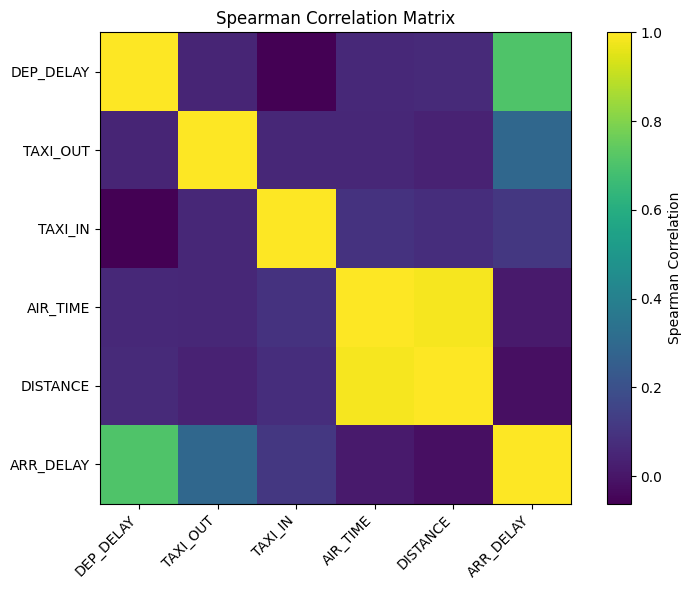

operational_variable,absolute_spearman_rho
DEP_DELAY,0.7068612127875593
TAXI_OUT,0.29361074734662296
TAXI_IN,0.10895900547262298
DISTANCE,0.017267864145313422
AIR_TIME,0.016142641774621998


In [0]:
import matplotlib.pyplot as plt

spearman_columns = [
    cfg.DEPARTURE_DELAY_COLUMN,
    cfg.TAXI_OUT_COLUMN,
    cfg.TAXI_IN_COLUMN,
    cfg.AIR_TIME_COLUMN,
    cfg.DISTANCE_COLUMN,
    cfg.ARRIVAL_DELAY_COLUMN,
]

spearman_frame = extended_analysis_pdf[spearman_columns].dropna()
spearman_corr = spearman_frame.corr(method="spearman")

display(spearman_corr.round(3))

departure_delay_spearman = stat.spearman_correlation(
    spearman_frame[cfg.DEPARTURE_DELAY_COLUMN],
    spearman_frame[cfg.ARRIVAL_DELAY_COLUMN],
)
extended_results.append(
    stat.build_test_result_row(
        research_question="RQ2",
        hypothesis_id="H2",
        null_hypothesis=(
            "There is no statistically significant relationship between "
            "operational factors and arrival delays."
        ),
        alternative_hypothesis=(
            "At least one operational factor has a statistically significant "
            "relationship with arrival delays."
        ),
        factor=(
            f"Spearman({cfg.DEPARTURE_DELAY_COLUMN}, "
            f"{cfg.ARRIVAL_DELAY_COLUMN})"
        ),
        test_output=departure_delay_spearman,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

plt.figure(figsize=(8, 6))
image = plt.imshow(spearman_corr, interpolation="nearest")
plt.colorbar(image, label="Spearman Correlation")
plt.xticks(
    range(len(spearman_corr.columns)),
    spearman_corr.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(spearman_corr.index)), spearman_corr.index)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

correlation_summary = (
    spearman_corr[cfg.ARRIVAL_DELAY_COLUMN]
    .drop(cfg.ARRIVAL_DELAY_COLUMN)
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
correlation_summary.columns = [
    "operational_variable",
    "absolute_spearman_rho",
]
display(correlation_summary)


#### Extended diagnostic interpretation

Chi-square tests in the earlier sections already report Cramér's V through the shared statistical utilities. In practice, several categorical factors can be statistically significant while showing negligible effect sizes in a dataset of this size.

The Kruskal-Wallis and Dunn analyses show that airline-level differences also appear in continuous arrival-delay minutes. Spearman correlation indicates that departure delay has the strongest monotonic association with arrival delay, while distance and air time show much weaker direct relationships.

These diagnostics support the modeling strategy: schedule-time variables are used for prediction, while post-departure operational outcomes are retained here for diagnostic interpretation only.

#### RQ4 and RQ5 — Deferred statistical validation

- **RQ4 / H4** will be evaluated in the operational-prioritization stage using optimization experiments that compare prioritized versus non-prioritized review strategies.
- **RQ5** will be evaluated in the SHAP explainability stage through model-interpretability analysis rather than a classical inferential hypothesis test.

These research questions remain part of the project design but are not statistically tested in this notebook.

#### Consolidate statistical evidence

All completed hypothesis tests are combined into a single results table for reporting and downstream dashboard use.

In [ ]:
extended_results_df = pd.DataFrame(extended_results)

statistical_results_pdf = pd.concat(
    [
        rq2_results_df,
        rq3_results_df,
        rq1_results_df,
        extended_results_df,
    ],
    ignore_index=True,
)


def _build_interpretation(row: pd.Series) -> str:
    text = (
        f"{row['decision']} at alpha={row['alpha']:.2f}; "
        f"effect size ({row['effect_size_label']})={row['effect_size']:.4f} "
        f"({row['effect_size_interpretation']} practical significance)"
    )
    if not row["assumptions_met"]:
        text += (
            "; NOTE: test assumptions were not fully met "
            "(see assumptions_met) - interpret with caution"
        )
    return text


statistical_results_pdf["interpretation"] = statistical_results_pdf.apply(
    _build_interpretation, axis=1
)

statistical_results_df = spark.createDataFrame(statistical_results_pdf)
display(statistical_results_df.orderBy("research_question", "factor"))

#### Research question validation summary

Use the consolidated results table to determine whether each research question is supported:

- **RQ2:** Supported if at least one operational factor shows a statistically significant association with `ARR_DEL15`.
- **RQ3:** Supported if airline or airport grouping shows a statistically significant difference in delay outcomes.
- **RQ1:** Supported statistically when schedule-time variables show significant association; final predictive confirmation occurs in model training.
- **RQ4 / RQ5:** Validated in later project stages.

In [0]:
validation_summary = (
    statistical_results_pdf
    .groupby("research_question", as_index=False)
    .agg(
        tests_run=("factor", "count"),
        significant_tests=("decision", lambda s: (s == "Reject H0").sum()),
        supported=(
            "decision",
            lambda s: "Yes" if (s == "Reject H0").any() else "No",
        ),
    )
)

display(spark.createDataFrame(validation_summary))


research_question,tests_run,significant_tests,supported
RQ1,3,3,Yes
RQ2,12,10,Yes
RQ3,4,4,Yes


#### Save statistical analysis results

The consolidated results are registered as a managed Delta table.

In [ ]:
(
    statistical_results_df.writeTo(cfg.STATISTICAL_RESULTS_TABLE)
    .using("delta")
    .createOrReplace()
)

print("Statistical analysis results saved successfully.")
print(f"Table: {cfg.STATISTICAL_RESULTS_TABLE}")
print(f"Total tests stored: {statistical_results_df.count():,}")